# SampleBuilding with Contexts — Shading 분석

OSM 파일에서 Shading 관련 객체를 추출하여 분석합니다.
- `OS:ShadingSurfaceGroup` : 차양 그룹 정보
- `OS:ShadingSurface` : 각 차양 면의 꼭짓점·Construction·Transmittance
- `OS:ShadowCalculation` : 그림자 계산 설정

In [5]:
import re
from pathlib import Path
import pandas as pd
import openstudio as op

In [6]:
print(op.openStudioVersion())

3.11.0


In [8]:
import re
from pathlib import Path
import pandas as pd

# 불러올 OSM 파일 경로 설정
osm_path = Path(r"SampleBuilding_with_contexts_sketchup_modified.osm")

# OSM 파일을 OpenStudio Path 형식으로 변환
os_path = op.path(str(osm_path))

# OSM 파일 불러오기
loaded = op.osversion.VersionTranslator().loadModel(os_path)

if not loaded.is_initialized():
    raise ValueError("OSM 파일을 불러오지 못했습니다.")

# OptionalModel에서 실제 Model 객체 꺼내기
model = loaded.get()

# 모델 내 공간/존/표면 개수 확인
print("Space 개수:", len(model.getSpaces()))
print("Thermal Zone 개수:", len(model.getThermalZones()))
print("Surface 개수:", len(model.getSurfaces()))

Space 개수: 23
Thermal Zone 개수: 23
Surface 개수: 210


## Shading Surface 출력하기

In [10]:
# Shading Surface 출력하기

shading_surfaces = model.getShadingSurfaces()
print("Shading Surface 개수:", len(shading_surfaces))
for i, shading_surface in enumerate(shading_surfaces):
    print(f"Shading Surface {i+1}: {shading_surface.nameString()}")

Shading Surface 개수: 2
Shading Surface 1: su-x-s-148
Shading Surface 2: su-x-s-149


In [14]:
# Shading Surface 정보 출력하기
for i, shading_surface in enumerate(shading_surfaces):
    print(f"\n{'='*50}")
    print(f"Shading Surface {i+1}:")
    print(f"{'='*50}")

    # 기본 정보
    print(f"  Name       : {shading_surface.nameString()}")

    # 그룹 및 타입
    group = shading_surface.shadingSurfaceGroup()
    if group.is_initialized():
        g = group.get()
        print(f"  Group Name : {g.nameString()}")
        print(f"  Type       : {g.shadingSurfaceType()}")  # Building / Space / Site
    else:
        print(f"  Group      : (없음)")

    # 면적
    print(f"  Gross Area : {shading_surface.grossArea():.4f} m²")

    # 꼭짓점 (Vertices)
    vertices = shading_surface.vertices()
    print(f"  Vertices ({len(vertices)}개):")
    for j, v in enumerate(vertices):
        print(f"    [{j+1}] X={v.x():.3f}, Y={v.y():.3f}, Z={v.z():.3f}")

    # Construction (레이어 구성)
    construction_opt = shading_surface.construction()
    if construction_opt.is_initialized():
        construction = construction_opt.get()
        print(f"  Construction : {construction.nameString()}")

        # LayeredConstruction으로 캐스팅하여 레이어 추출
        layered = construction.to_LayeredConstruction()
        if layered.is_initialized():
            layers = layered.get().layers()
            print(f"  Layers ({len(layers)}개):")
            for k, layer in enumerate(layers):
                print(f"    Layer {k+1}: {layer.nameString()}")

                # StandardOpaqueMaterial
                opaque = layer.to_StandardOpaqueMaterial()
                if opaque.is_initialized():
                    m = opaque.get()
                    print(f"      종류       : StandardOpaqueMaterial")
                    print(f"      두께       : {m.thickness():.4f} m")
                    print(f"      열전도율   : {m.thermalConductivity():.4f} W/m·K")
                    print(f"      밀도       : {m.density():.2f} kg/m³")
                    print(f"      비열       : {m.specificHeat():.2f} J/kg·K")
                    r = m.thickness() / m.thermalConductivity()
                    print(f"      R-value    : {r:.4f} m²·K/W")
                    continue

                # MasslessOpaqueMaterial
                massless = layer.to_MasslessOpaqueMaterial()
                if massless.is_initialized():
                    m = massless.get()
                    print(f"      종류       : MasslessOpaqueMaterial")
                    print(f"      R-value    : {m.thermalResistance():.4f} m²·K/W")
                    continue

                # SimpleGlazing
                glazing = layer.to_SimpleGlazing()
                if glazing.is_initialized():
                    m = glazing.get()
                    print(f"      종류       : SimpleGlazing")
                    print(f"      U-factor   : {m.uFactor():.4f} W/m²·K")
                    print(f"      SHGC       : {m.solarHeatGainCoefficient():.4f}")
                    continue

                # StandardGlazing
                std_glazing = layer.to_StandardGlazing()
                if std_glazing.is_initialized():
                    m = std_glazing.get()
                    print(f"      종류       : StandardGlazing")
                    print(f"      두께       : {m.thickness():.4f} m")
                    print(f"      열전도율   : {m.thermalConductivity():.4f} W/m·K")
                    continue

                print(f"      종류       : {layer.iddObjectType().valueName()}")
        else:
            print(f"  Layers     : LayeredConstruction 아님 (단순 Construction)")
    else:
        print(f"  Construction : (없음, 기본값 사용)")

    # Transmittance Schedule
    sched = shading_surface.transmittanceSchedule()
    if sched.is_initialized():
        print(f"  Transmittance Schedule: {sched.get().nameString()}")
    else:
        print(f"  Transmittance Schedule: (없음, 일정한 투과율)")


Shading Surface 1:
  Name       : su-x-s-148
  Group Name : {0abf964f-2e37-42b0-98f5-b0273ceddd3e}
  Type       : Building
  Gross Area : 480.0000 m²
  Vertices (4개):
    [1] X=51.873, Y=-3.278, Z=16.000
    [2] X=51.873, Y=-3.278, Z=0.000
    [3] X=30.660, Y=17.936, Z=0.000
    [4] X=30.660, Y=17.936, Z=16.000
  Construction : (없음, 기본값 사용)
  Transmittance Schedule: (없음, 일정한 투과율)

Shading Surface 2:
  Name       : su-x-s-149
  Group Name : {0abf964f-2e37-42b0-98f5-b0273ceddd3e}
  Type       : Building
  Gross Area : 640.0000 m²
  Vertices (4개):
    [1] X=18.498, Y=17.936, Z=16.000
    [2] X=18.498, Y=17.936, Z=0.000
    [3] X=-9.786, Y=-10.349, Z=0.000
    [4] X=-9.786, Y=-10.349, Z=16.000
  Construction : (없음, 기본값 사용)
  Transmittance Schedule: (없음, 일정한 투과율)


gbXML → OpenStudio 변환 시 surfaceType="Shade" 면은:   
- 보존되는 것: 기하학적 형상(꼭짓점, 면적, 방위각)만   
- 버려지는 것: 재료/construction 정보 전체   
- 따라서 시뮬레이션에서는 완전 불투명 차양(투과율 0, 열전달 없음) 으로만 작동하며, 원래 con-r-0metalframewall(석고보드 벽체)이었던 재료 정보는 사실상 사용 x   

 ┌──────────────┬──────────────────────────────────────────┐   
  │   카테고리   │                   항목                   │   
  ├──────────────┼──────────────────────────────────────────┤   
  │ 기본         │ 이름, 그룹명, 타입 (Building/Space/Site) │   
  ├──────────────┼──────────────────────────────────────────┤   
  │ 형상         │ 면적(m²), 꼭짓점 XYZ 좌표                │   
  ├──────────────┼──────────────────────────────────────────┤   
  │ Construction │ 레이어 목록, 각 레이어 이름              │   
  ├──────────────┼──────────────────────────────────────────┤   
  │ 불투명 재료  │ 두께, 열전도율, 밀도, 비열, R-value      │   
  ├──────────────┼──────────────────────────────────────────┤   
  │ 유리 재료    │ U-factor, SHGC, 두께                     │   
  ├──────────────┼──────────────────────────────────────────┤   
  │ 스케줄       │ 투과율 스케줄 이름                       │   
  └──────────────┴──────────────────────────────────────────┘   

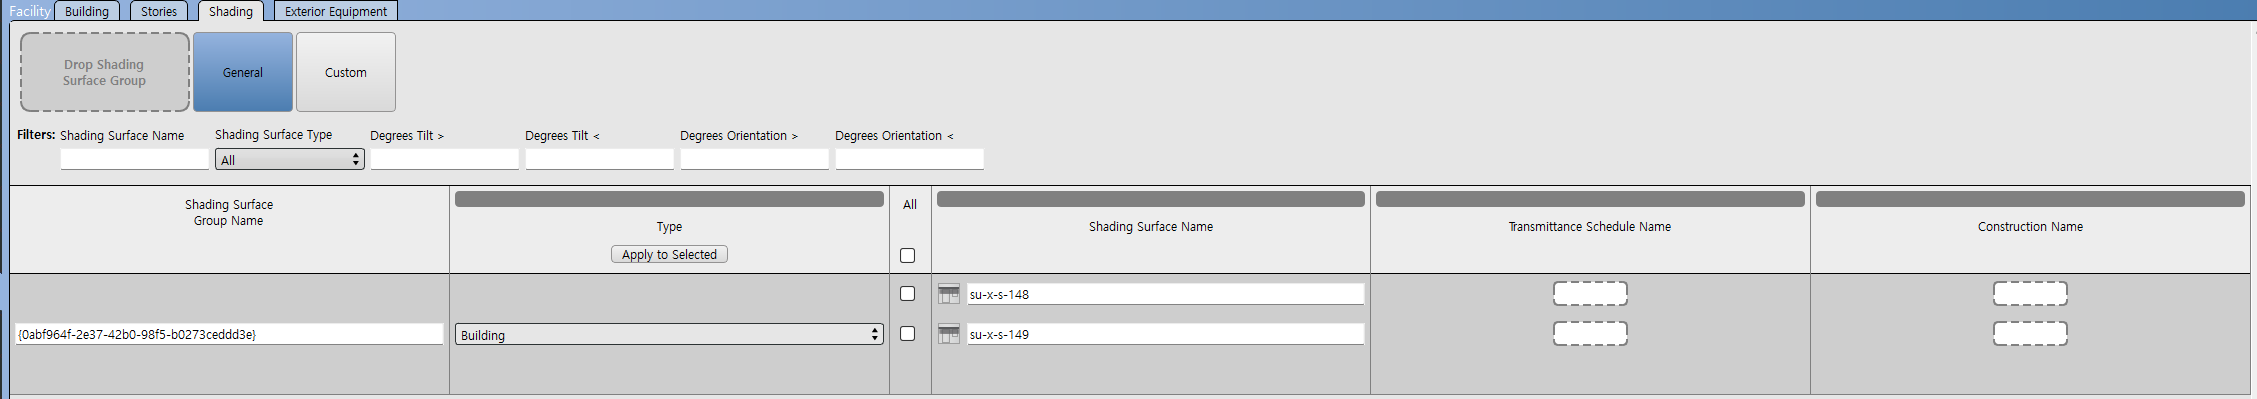